<div style="background-color:#0b0b0b; border:1px solid #1f1f1f; border-radius:10px; padding:14px 16px; margin:10px 0;">
  <div style="display:flex; align-items:center; gap:10px; flex-wrap:wrap;">
    <img
      src="https://open.spotify.com/favicon.ico"
      alt="Spotify"
      width="24"
      height="24"
      style="border-radius:4px;"
    >
    <span style="color:#45d979; font-weight:700; font-size:18px;">
    2. Spotify — Análise de Dados Pessoais
    </span>
    <span style="color:#cfcfcf; font-size:14px;">
       <strong>user:@victorjvc</strong>
    </span>
  </div>
 
  <p style="color:#d7d7d7; margin:10px 0 0;">
    Projeto de exploração de hábitos de escuta a partir dos dados pessoais exportados pelo Spotify.
  </p>

</div>

<div style="background-color:#0b0b0b; border:1px solid #1f1f1f; border-radius:10px; padding:14px 16px; margin:10px 0;">
<span style="#FFFFFF">
O intuito desse projeto é ver os meus hábitos no Spotify no ano de 2025, como um <i>Spotify Wrapped</i>
home made!<br>

Para obter os dados, basta acessar [https://www.spotify.com/br-pt/account/privacy/](https://www.spotify.com/br-pt/account/privacy/) e solicitar os seus dados pessoais. Você os receberá por e-mail em um conjunto de JSONs acompanhado de um PDF com instruções.


</span>
</div>

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
# Carregando os Dados
DIR_DATA = Path("../spotify_data")
json_files = [f for f in DIR_DATA.iterdir() if not f.name.endswith("pdf")]

print(f"{' FILES obtained with Spotify ':=^100}")
for i, f in enumerate(json_files):
    print(f"{i:.<30} {f.name:>30} ")
print("="*100)    

# Obtendo dados de 2025
jsons_2025 = [json_files[10], json_files[12]]
df = pd.concat([pd.read_json(json_f) for json_f in jsons_2025])
print("\nDataFrame 2025\n")
display(df.sample(5))

=================================== FILES obtained with Spotify ====================================
0............................. Streaming_History_Audio_2016-2018_0.json 
1............................. Streaming_History_Audio_2018-2019_1.json 
2............................. Streaming_History_Audio_2019-2020_2.json 
3............................. Streaming_History_Audio_2020-2021_4.json 
4............................. Streaming_History_Audio_2020_3.json 
5............................. Streaming_History_Audio_2021-2022_5.json 
6............................. Streaming_History_Audio_2022-2023_7.json 
7............................. Streaming_History_Audio_2022_6.json 
8............................. Streaming_History_Audio_2023-2024_9.json 
9............................. Streaming_History_Audio_2023_8.json 
10............................ Streaming_History_Audio_2024-2025_11.json 
11............................ Streaming_History_Audio_2024_10.json 
12............................ Streaming_

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
891,2025-10-17T23:19:54Z,android,138885,BR,2804:14c:5bd6:a4b4:b2a2:1f93:94d8:3922,Amando Você,João Gomes,Digo Ou Não Digo,spotify:track:4WDdWpw9aQ3eyo6OyY8zQl,None,...,NaN,NaN,NaN,trackdone,logout,False,False,False,1760742453,False
695,2024-11-03T16:42:05Z,windows,100750,BR,201.17.210.178,stuck in my head,LochHaven,stuck in my head,spotify:track:3AIyvGUELsmZyD8u6o5BbR,None,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,1730652024,False
496,2024-10-29T22:40:04Z,android,11307,BR,2804:18:902:bde:1802:eb15:8049:9dee,Brincar de Viver,Guilherme Arantes,Despertar,spotify:track:72OYbJH5brGfFBR3AJez3m,None,...,NaN,NaN,NaN,trackdone,fwdbtn,False,True,False,1730241591,False
202,2024-10-25T02:21:41Z,android,129640,BR,2804:14c:5bd7:8144:86db:2b73:493d:daee,Godspeed,Frank Ocean,Blonde,spotify:track:34xTFwjPQ1dC6uJmleno7x,None,...,NaN,NaN,NaN,clickrow,endplay,False,True,False,1729822507,False
8379,2025-05-06T21:45:10Z,android,6752,BR,2804:18:405a:ecdc:1:0:4721:7347,When A Blind Man Cries - Remastered,Deep Purple,Machine Head,spotify:track:0JtcFIgrkSagrM5JdFakeO,None,...,NaN,NaN,NaN,fwdbtn,fwdbtn,False,True,False,1746567903,False


## Entendendo os Dados

A descrição abaixo foi obtida do arquivo 📁[../spotify_data/ReadMeFirst_ExtendedStreamingHistory.pdf](../spotify_data/ReadMeFirst_ExtendedStreamingHistory.pdf)

---

***ts***: Este campo é um carimbo de data/hora indicando quando a faixa parou de ser tocada em formato UTC (Tempo Universal Coordenado). A ordem é ano, mês e dia, seguida por um carimbo de data/hora no formato de horário militar.

***plataform***: Este campo é a plataforma usada para streaming da faixa
(como Android OS, Google Chromecast).

***ms_played***: Este campo é a duração do streaming, em milésimos de
segundo.

***master_metadata_track_name***: Este campo é o nome da faixa.

***master_metadata_album_artist_name***: Este campo é o nome do artista, da banda ou do podcast

***master_metadata_album_album_name***: Este campo é o nome do álbum ou da faixa

***reason_start***: Este campo é um valor informando por que a faixa foi
reproduzida (por exemplo, “trackdone”).

***reason_end***: Este campo é um valor informando por que a faixa foi
encerrada (por exemplo, “endplay”).

***shuffle***: Este campo tem o valor "True" ou "False" para indicar se o
modo "ordem aleatória" foi usado ao tocar a faixa.

***skipped***: Este campo indica se o usuário pulou para a próxima
música.

***offline***: Este campo indica se uma faixa foi ouvida no modo offline
(“True”) ou não (“False”).

***offline_timestamp***: Este campo é um carimbo de data/hora de quando o modo offline foi usado, se tiver sido usado.

---

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18545 entries, 0 to 2931
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ts                                 18545 non-null  object 
 1   platform                           18545 non-null  object 
 2   ms_played                          18545 non-null  int64  
 3   conn_country                       18545 non-null  object 
 4   ip_addr                            18545 non-null  object 
 5   master_metadata_track_name         18467 non-null  object 
 6   master_metadata_album_artist_name  18467 non-null  object 
 7   master_metadata_album_album_name   18467 non-null  object 
 8   spotify_track_uri                  18467 non-null  object 
 9   episode_name                       78 non-null     object 
 10  episode_show_name                  78 non-null     object 
 11  spotify_episode_uri                78 non-null     object 
 

Há algumas colunas com dados nulos que envolvem os episódios e audiobooks, que particularmente eu não escuto tão frequentemente. Irei remover da análise no geral. Mas antes da remoção, a critério de curiosidade vou ver quais foram os registros não nulos.

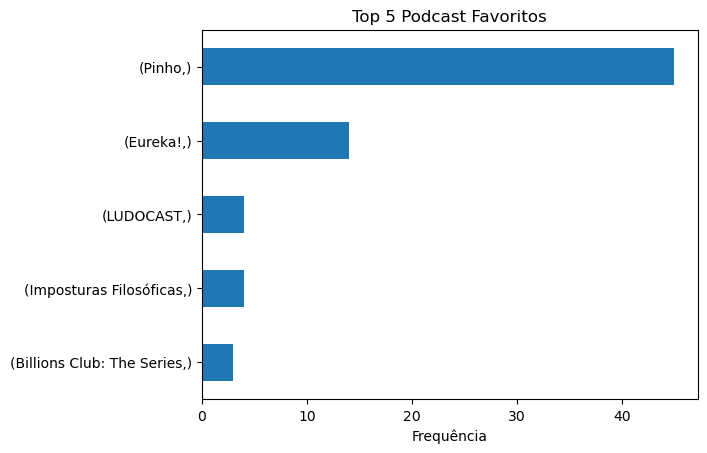

In [4]:
not_music: list[str] = [col for col in df.columns.tolist() if "episode" in col or "audiobook" in col]

podcast_df = df[
    df[not_music].notna().any(axis=1)
][not_music].copy()
podcast_df

# Top 5 Podcasts Favoritos
podcast_count = podcast_df[
    ["episode_show_name"]    
].value_counts().sort_values(ascending=True).tail()

podcast_count.plot(kind="barh", xlabel="Frequência", title="Top 5 Podcast Favoritos", ylabel="")
plt.show()

In [5]:
# Remoção de podcast e colunas desnecessárias
colsdrop = ["conn_country", "ip_addr", "spotify_track_uri", "incognito_mode", "offline", "offline_timestamp"] + not_music
df.drop(columns=colsdrop, inplace=True)

## Renomeando e Selecionando Colunas

In [6]:
df = df.rename(
    columns={"master_metadata_track_name":"track_name",
    "master_metadata_album_artist_name": "artist_name",
    "master_metadata_album_album_name": "album"
    }
)
df.head()

,ts,platform,ms_played,track_name,artist_name,album,reason_start,reason_end,shuffle,skipped
0,2024-10-21T00:42:30Z,android,26780,Se Fiquei Esperando Meu Amor Passar,Legião Urbana,As Quatro Estações,clickrow,endplay,False,True
1,2024-10-21T00:54:38Z,android,127180,Giz,Legião Urbana,Mais Do Mesmo,clickrow,logout,False,False
2,2024-10-21T10:04:16Z,android,30780,VELUDO MARROM,Liniker,CAJU,playbtn,logout,True,False
3,2024-10-21T10:59:11Z,android,405,Não aprendi a dizer adeus,Leandro & Leonardo,Volume 5,clickrow,endplay,False,True
4,2024-10-21T11:03:16Z,android,246026,Dois Corações e uma História,Zezé Di Camargo & Luciano,Zezé Di Camargo & Luciano 1998,clickrow,trackdone,False,False


## Conversão para datetime e colunas auxiliares

In [7]:
df["ts"] = pd.to_datetime(df["ts"])

df["year"] = df["ts"].dt.year
df["month"] = df["ts"].dt.month
df["weekday"] = df["ts"].dt.weekday
df["day"] = df["ts"].dt.day
df["time"] = df["ts"].dt.time
df.head()

,ts,platform,ms_played,track_name,artist_name,album,reason_start,reason_end,shuffle,skipped,year,month,weekday,day,time
0,2024-10-21 00:42:30+00:00,android,26780,Se Fiquei Esperando Meu Amor Passar,Legião Urbana,As Quatro Estações,clickrow,endplay,False,True,2024,10,0,21,00:42:30
1,2024-10-21 00:54:38+00:00,android,127180,Giz,Legião Urbana,Mais Do Mesmo,clickrow,logout,False,False,2024,10,0,21,00:54:38
2,2024-10-21 10:04:16+00:00,android,30780,VELUDO MARROM,Liniker,CAJU,playbtn,logout,True,False,2024,10,0,21,10:04:16
3,2024-10-21 10:59:11+00:00,android,405,Não aprendi a dizer adeus,Leandro & Leonardo,Volume 5,clickrow,endplay,False,True,2024,10,0,21,10:59:11
4,2024-10-21 11:03:16+00:00,android,246026,Dois Corações e uma História,Zezé Di Camargo & Luciano,Zezé Di Camargo & Luciano 1998,clickrow,trackdone,False,False,2024,10,0,21,11:03:16


In [10]:
df.shape

(18545, 15)

In [12]:
df.query("year == 2025").to_csv("spotify2025.csv",index=False)

In [16]:
pd.read_csv("spotify2025.csv").shape

(15139, 15)

---